In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [58]:
import sqlite3
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from category_encoders import OneHotEncoder
from IPython.display import VimeoVideo
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.utils.validation import check_is_fitted

# **PREPARE DATA**

In [59]:
import pandas as pd

def wrangle(csv_path):
    # Read CSV into DataFrame
    df = pd.read_csv(csv_path)
    
    # Identify Leaky columns
    drop_cols = [col for col in df.columns if "post_eq" in col]

    # Create Binary col
    df["damage_grade"] = df["damage_grade"].str[-1].astype(int)
    df["severe_damage"] = (df["damage_grade"] > 3).astype(int)

    # Drop "damage_grade" col
    drop_cols.append("damage_grade")

    # Drop Multicollinearity columns
    drop_cols.append("count_floors_pre_eq")

    # Drop high cardinality columns (if it exists)
    if "building_id" in df.columns:
        drop_cols.append("building_id")

    # Drop Leaky columns
    df.drop(columns=drop_cols, inplace=True)

    return df

In [60]:
import os

os.listdir("/kaggle/input/datasets/domingosnhamussusa/earthquake-damage-in-nepal")

['NepalEarhquakeDamage2015.csv']

In [61]:
import pandas as pd

def wrangle(csv_path):
    # Read CSV
    df = pd.read_csv(csv_path)
    
    # Drop rows with missing damage_grade
    df = df.dropna(subset=["damage_grade"])

    # Identify leaky columns
    drop_cols = [col for col in df.columns if "post_eq" in col]

    # Convert damage_grade to integer safely
    df["damage_grade"] = df["damage_grade"].str[-1].astype(int)
    df["severe_damage"] = (df["damage_grade"] > 3).astype(int)

    # Drop columns
    drop_cols.append("damage_grade")
    if "count_floors_pre_eq" in df.columns:
        drop_cols.append("count_floors_pre_eq")
    if "building_id" in df.columns:
        drop_cols.append("building_id")

    df.drop(columns=drop_cols, inplace=True)

    return df

In [62]:
df = wrangle("/kaggle/input/datasets/domingosnhamussusa/earthquake-damage-in-nepal/NepalEarhquakeDamage2015.csv")
df.head()

,district_id,age_building,plinth_area_sq_ft,height_ft_pre_eq,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,plan_configuration,severe_damage
0,12,9,288,9,Flat,Other,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,Rectangular,0
1,12,15,364,9,Flat,Other,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,Rectangular,1
2,12,20,384,9,Flat,Other,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,Rectangular,0
3,12,20,312,9,Flat,Other,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,Rectangular,0
4,12,30,308,9,Flat,Other,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,Rectangular,0


In [63]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 762094 entries, 0 to 762105
Data columns (total 12 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   district_id             762094 non-null  int64 
 1   age_building            762094 non-null  int64 
 2   plinth_area_sq_ft       762094 non-null  int64 
 3   height_ft_pre_eq        762094 non-null  int64 
 4   land_surface_condition  762094 non-null  object
 5   foundation_type         762094 non-null  object
 6   roof_type               762094 non-null  object
 7   ground_floor_type       762094 non-null  object
 8   other_floor_type        762094 non-null  object
 9   position                762094 non-null  object
 10  plan_configuration      762094 non-null  object
 11  severe_damage           762094 non-null  int64 
dtypes: int64(5), object(7)
memory usage: 75.6+ MB
None


In [64]:
print(df["severe_damage"].value_counts())

severe_damage
1    459610
0    302484
Name: count, dtype: int64


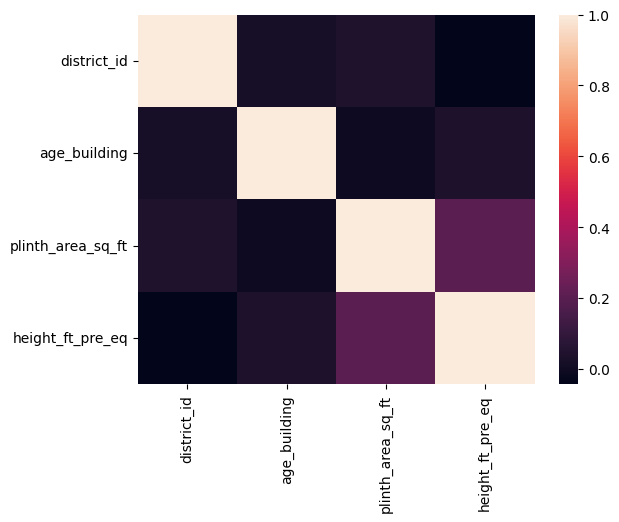

In [65]:
# Create correlation matrix
correlation = df.select_dtypes("number").drop(columns="severe_damage").corr()
# Plot heatmap of `correlation`
sns.heatmap(correlation);

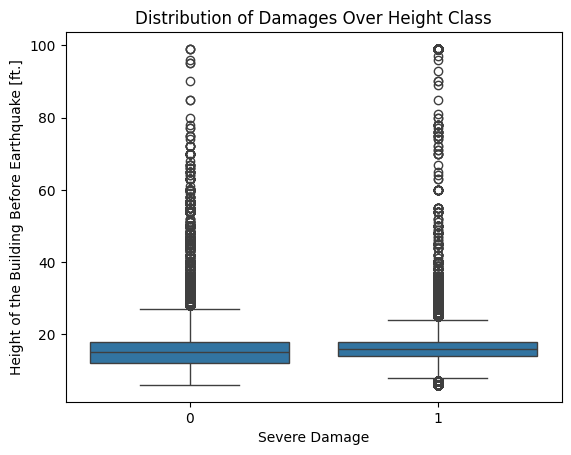

In [66]:
# Create boxplot
sns.boxplot(x="severe_damage", y="height_ft_pre_eq", data=df)
# Label axes
plt.xlabel("Severe Damage")
plt.ylabel("Height of the Building Before Earthquake [ft.]")
plt.title("Distribution of Damages Over Height Class");

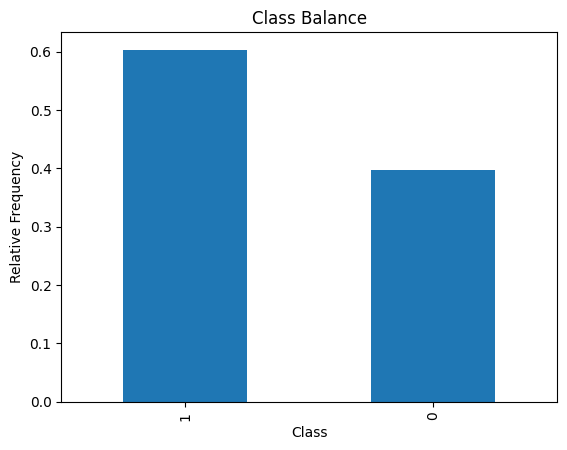

In [67]:
# Plot value counts of `"severe_damage"`
df["severe_damage"].value_counts(normalize=True).plot(
    kind="bar", xlabel="Class", ylabel="Relative Frequency", title="Class Balance"
);

In [68]:
majority_class_prop, minority_class_prop = df["severe_damage"].value_counts(normalize=True)
print(majority_class_prop, minority_class_prop)

0.6030883329353072 0.39691166706469283


In [69]:
# Create pivot table
foundation_pivot = pd.pivot_table(
    df, index="foundation_type", values="severe_damage", aggfunc= np.mean
).sort_values(by="severe_damage")
foundation_pivot

/tmp/ipykernel_55/1341094657.py:2: FutureWarning: The provided callable <function mean at 0x7a393050c220> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  foundation_pivot = pd.pivot_table(


,severe_damage
foundation_type,
RC,0.038263
Bamboo/Timber,0.237855
Cement-Stone/Brick,0.296904
Other,0.510545
Mud mortar-Stone/Brick,0.685115


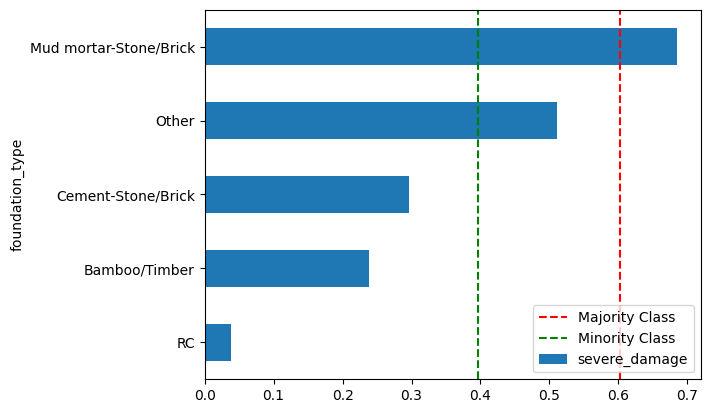

In [70]:
# Plot bar chart of `foundation_pivot`
foundation_pivot.plot(kind="barh")
plt.axvline(
    majority_class_prop, color="red", linestyle="--", label="Majority Class"
)
plt.axvline(
    minority_class_prop, color="green", linestyle="--", label="Minority Class"
)
plt.legend(loc="lower right");

In [71]:
# Check for high- and low-cardinality categorical features
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 762094 entries, 0 to 762105
Data columns (total 12 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   district_id             762094 non-null  int64 
 1   age_building            762094 non-null  int64 
 2   plinth_area_sq_ft       762094 non-null  int64 
 3   height_ft_pre_eq        762094 non-null  int64 
 4   land_surface_condition  762094 non-null  object
 5   foundation_type         762094 non-null  object
 6   roof_type               762094 non-null  object
 7   ground_floor_type       762094 non-null  object
 8   other_floor_type        762094 non-null  object
 9   position                762094 non-null  object
 10  plan_configuration      762094 non-null  object
 11  severe_damage           762094 non-null  int64 
dtypes: int64(5), object(7)
memory usage: 75.6+ MB


# **SPLIT DATA**

In [72]:
target = "severe_damage"
X = df.drop(columns="severe_damage")
y = df[target]

In [73]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size= 0.2, random_state= 42
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (609675, 11)
y_train shape: (609675,)
X_test shape: (152419, 11)
y_test shape: (152419,)


# **BASELINE ACCURACY**

In [74]:
acc_baseline = y_train.value_counts(normalize=True).max()
print("Baseline Accuracy:", round(acc_baseline, 2))

Baseline Accuracy: 0.6


# **BUILD MODEL**

In [75]:
# Build model
model = make_pipeline(
    OneHotEncoder(use_cat_names=True),
    LogisticRegression(max_iter=1000)
)
# Fit model to training data
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline(steps=[('onehotencoder',
                 OneHotEncoder(cols=['land_surface_condition',
                                     'foundation_type', 'roof_type',
                                     'ground_floor_type', 'other_floor_type',
                                     'position', 'plan_configuration'],
                               use_cat_names=True)),
                ('logisticregression', LogisticRegression(max_iter=1000))])

In [76]:
acc_train = accuracy_score(y_train, model.predict(X_train))
acc_test = model.score(X_test, y_test)

print("Training Accuracy:", round(acc_train, 2))
print("Test Accuracy:", round(acc_test, 2))

Training Accuracy: 0.72
Test Accuracy: 0.72


In [77]:
y_train_pred_proba = model.predict_proba(X_train)
print(y_train_pred_proba[:5])

[[0.26975553 0.73024447]
 [0.28285844 0.71714156]
 [0.24131585 0.75868415]
 [0.32114323 0.67885677]
 [0.26063305 0.73936695]]


In [78]:
features = model.named_steps["onehotencoder"].get_feature_names()
importances = model.named_steps["logisticregression"].coef_[0]

/tmp/ipykernel_55/1294114254.py:1: FutureWarning: `get_feature_names` is deprecated in all of sklearn. Use `get_feature_names_out` instead.
  features = model.named_steps["onehotencoder"].get_feature_names()


In [79]:
odds_ratios = pd.Series(np.exp(importances), index=features).sort_values()
odds_ratios.head()

ground_floor_type_RC             0.295807
roof_type_RCC/RB/RBC             0.360994
foundation_type_Bamboo/Timber    0.363253
foundation_type_RC               0.481654
plan_configuration_L-shape       0.552351
dtype: float64

# **COMMUNICATE RESULTS**

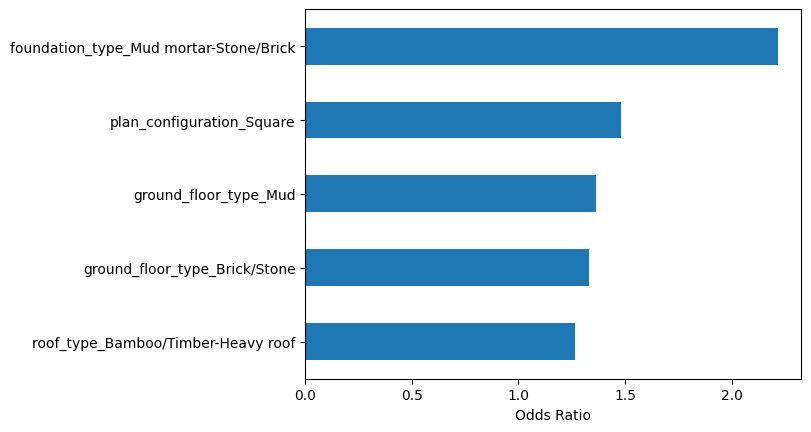

In [80]:
# Horizontal bar chart, five largest coefficients
odds_ratios.tail().plot(kind="barh")
plt.xlabel("Odds Ratio");

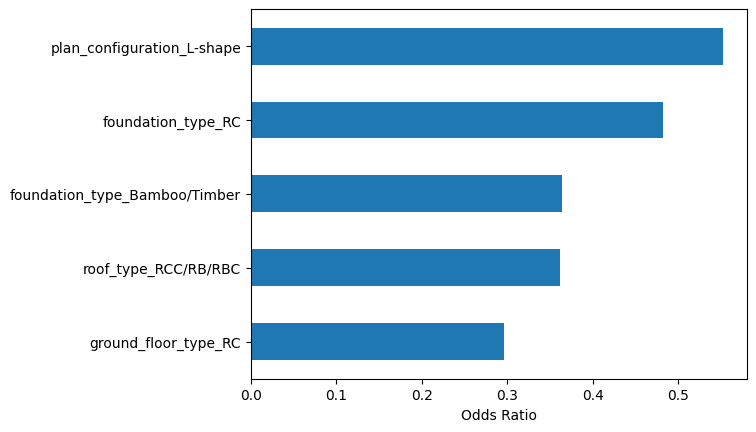

In [81]:
# Horizontal bar chart, five smallest coefficients
odds_ratios.head().plot(kind="barh")
plt.xlabel("Odds Ratio");